# Mutual Fund Performance Analytics

This notebook computes risk-adjusted performance metrics for mutual fund schemes and compares them against benchmark indices.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "data/raw/02_nav_history.csv"
)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [4]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

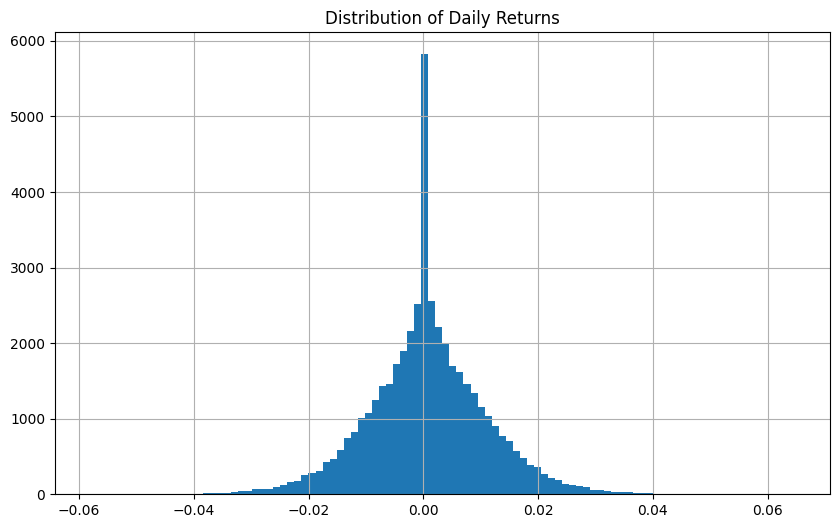

In [6]:
plt.figure(figsize=(10,6))

nav["daily_return"].hist(
    bins=100
)

plt.title("Distribution of Daily Returns")

plt.show()

### Insight

Daily returns are centered near zero and approximately normally distributed, which is typical for diversified mutual fund portfolios.

# CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized return generated by a fund over a specific period.

In [7]:
nav.head()


,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547


In [8]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [9]:
cagr_data = (
    nav.groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last"),
        start_date=("date", "first"),
        end_date=("date", "last")
    )
)

cagr_data.head()

,start_nav,end_nav,start_date,end_date
amfi_code,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29
100025,26.3169,31.8843,2022-01-03,2026-05-29
100033,107.3758,342.0072,2022-01-03,2026-05-29
101206,305.0996,773.2939,2022-01-03,2026-05-29
101207,38.5736,53.9836,2022-01-03,2026-05-29


In [10]:
cagr_data["years"] = (
    cagr_data["end_date"] -
    cagr_data["start_date"]
).dt.days / 365

cagr_data.head()

,start_nav,end_nav,start_date,end_date,years
amfi_code,,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29,4.40274
100025,26.3169,31.8843,2022-01-03,2026-05-29,4.40274
100033,107.3758,342.0072,2022-01-03,2026-05-29,4.40274
101206,305.0996,773.2939,2022-01-03,2026-05-29,4.40274
101207,38.5736,53.9836,2022-01-03,2026-05-29,4.40274


In [11]:
cagr_data["cagr"] = (
    (
        cagr_data["end_nav"]
        / cagr_data["start_nav"]
    ) ** (
        1 / cagr_data["years"]
    )
) - 1

cagr_data.head()

,start_nav,end_nav,start_date,end_date,years,cagr
amfi_code,,,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29,4.40274,0.026352
100025,26.3169,31.8843,2022-01-03,2026-05-29,4.40274,0.044551
100033,107.3758,342.0072,2022-01-03,2026-05-29,4.40274,0.300997
101206,305.0996,773.2939,2022-01-03,2026-05-29,4.40274,0.235205
101207,38.5736,53.9836,2022-01-03,2026-05-29,4.40274,0.079331


In [12]:
cagr_data["cagr_pct"] = (
    cagr_data["cagr"] * 100
)

cagr_data[
    ["cagr_pct"]
].sort_values(
    by="cagr_pct",
    ascending=False
).head(10)

,cagr_pct
amfi_code,
120505,32.801599
119598,32.398084
149324,32.262108
148569,31.924486
148567,30.949920
120843,30.883326
100033,30.099704
149323,29.558105
119094,28.192608


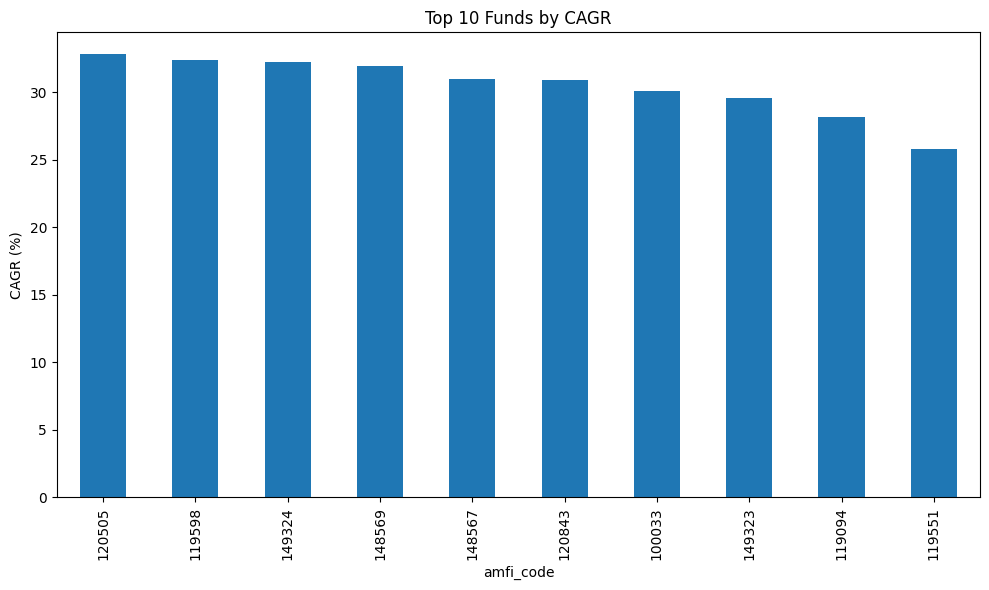

In [13]:
top_cagr = (
    cagr_data["cagr_pct"]
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_cagr.plot(kind="bar")

plt.title("Top 10 Funds by CAGR")
plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.show()

### Insight

The top-performing funds generated the highest annualized growth rates over the available NAV history, demonstrating superior long-term compounding performance.

In [14]:
cagr_data.to_csv(
    "reports/cagr_analysis.csv"
)

In [15]:
rf = 0.065
daily_rf = rf / 252

daily_rf

0.00025793650793650796

In [16]:
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(
        mean_return="mean",
        std_return="std"
    )
)

sharpe.head()

,mean_return,std_return
amfi_code,,
100016,0.000142,0.009164
100025,0.000170,0.002460
100033,0.001080,0.011929
101206,0.000852,0.009177
101207,0.000424,0.016251


In [17]:
sharpe["sharpe_ratio"] = (
    (
        sharpe["mean_return"] - daily_rf
    )
    /
    sharpe["std_return"]
) * np.sqrt(252)

sharpe.head()

,mean_return,std_return,sharpe_ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [18]:
top_sharpe = (
    sharpe["sharpe_ratio"]
    .sort_values(
        ascending=False
    )
)

top_sharpe.head(10)

amfi_code
148567    1.448291
120843    1.306744
148569    1.234930
119551    1.208267
120505    1.180101
149323    1.132122
100033    1.093699
118632    1.081659
101206    1.027213
120504    1.026524
Name: sharpe_ratio, dtype: float64

Task was destroyed but it is pending!
task: <Task pending name='Task-172' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\KIIT\Desktop\Mutual-Fund-Analytics\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-173' coro=<Kernel.shell_main() running at C:\Users\KIIT\Desktop\Mutual-Fund-Analytics\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\KIIT\Desktop\Mutual-Fund-Analytics\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Exception ignored while finalizing coroutine <coroutine object Kernel.shell_main at 0x0000020A5F1EBCD0>:
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored while finalizing coroutine <coroutine object Kernel.shell_main at 0x0000020A5F1EBCD0>:
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destro

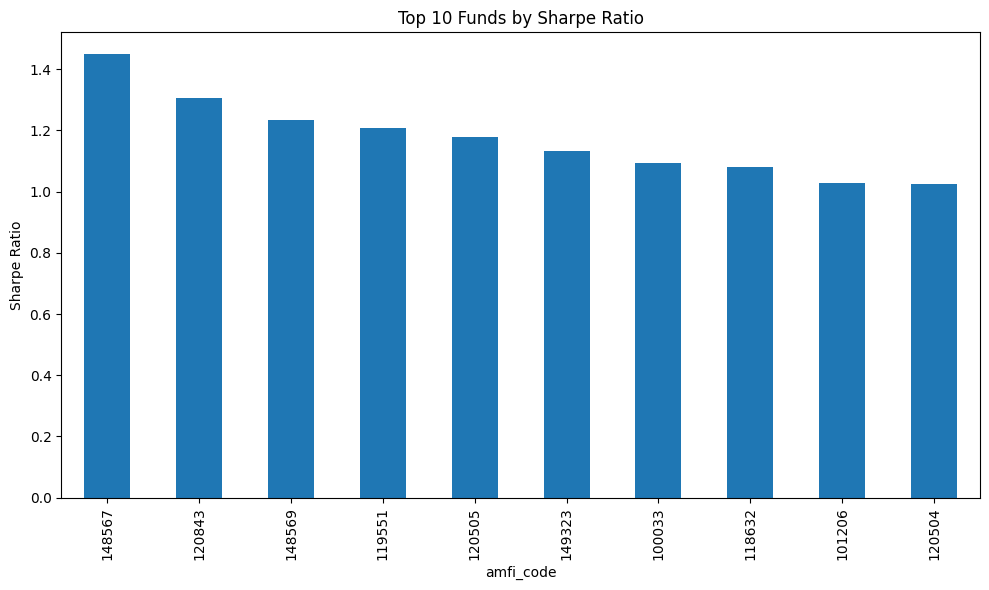

In [19]:
plt.figure(figsize=(10,6))

top_sharpe.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.tight_layout()

plt.show()

### Insight

Funds with higher Sharpe Ratios generated superior risk-adjusted returns, indicating better compensation for the volatility undertaken by investors.

In [20]:
sharpe.to_csv(
    "reports/sharpe_ratio.csv"
)

In [21]:
def calculate_sortino(group):
    
    mean_return = group.mean()
    
    downside_returns = group[group < 0]
    
    downside_std = downside_returns.std()
    
    sortino = (
        (mean_return - daily_rf)
        /
        downside_std
    ) * np.sqrt(252)
    
    return sortino

In [22]:
sortino = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(calculate_sortino)
)

sortino = sortino.to_frame(
    name="sortino_ratio"
)

sortino.head()

,sortino_ratio
amfi_code,
100016,-0.351047
100025,-0.941821
100033,1.829134
101206,1.799563
101207,0.276644


In [23]:
sortino.sort_values(
    by="sortino_ratio",
    ascending=False
).head(10)

,sortino_ratio
amfi_code,
148567,2.385644
120843,2.364320
148569,2.146914
119551,2.140267
120505,2.029353
149323,1.875101
118632,1.850133
100033,1.829134
120504,1.805294


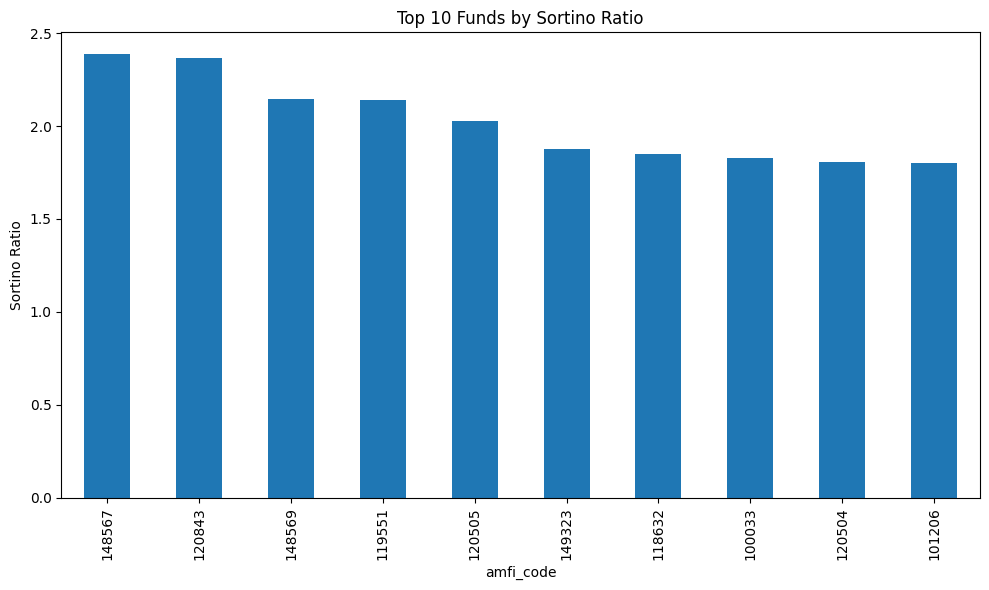

In [24]:
plt.figure(figsize=(10,6))

(
    sortino["sortino_ratio"]
    .sort_values(
        ascending=False
    )
    .head(10)
    .plot(kind="bar")
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.ylabel(
    "Sortino Ratio"
)

plt.tight_layout()

plt.show()

### Insight

The Sortino Ratio focuses only on harmful volatility. Funds with high Sortino Ratios delivered stronger returns while experiencing fewer significant downside movements.

In [25]:
sortino.to_csv(
    "reports/sortino_ratio.csv"
)

In [26]:
benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [27]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [28]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [29]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [40]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [31]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return


In [41]:
nifty100.shape

(1150, 3)

In [43]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [45]:
nifty100 = nifty100[
    ["date", "benchmark_return"]
]

In [46]:
alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        result = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = result.intercept * 252
        beta = result.slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

In [47]:
alpha_beta = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,119551,0.232010,-0.031751
1,119552,0.198686,-0.026159
2,119598,0.303370,-0.023196
3,119599,0.048824,0.062002
4,119120,0.056209,-0.006414


In [48]:
alpha_beta["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [49]:
drawdown_results = []

In [50]:
for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        /
        fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )

In [51]:
max_drawdown = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_drawdown.head()

,amfi_code,max_drawdown
0,119551,-0.150124
1,119552,-0.118035
2,119598,-0.287060
3,119599,-0.525742
4,119120,-0.043287


In [52]:
max_drawdown.sort_values(
    by="max_drawdown"
).head(10)

,amfi_code,max_drawdown
3,119599,-0.525742
27,119095,-0.516778
29,101207,-0.354469
39,149324,-0.311719
2,119598,-0.287060
32,102886,-0.280011
5,100016,-0.247344
21,120842,-0.240035
17,118634,-0.233449
25,119093,-0.217514


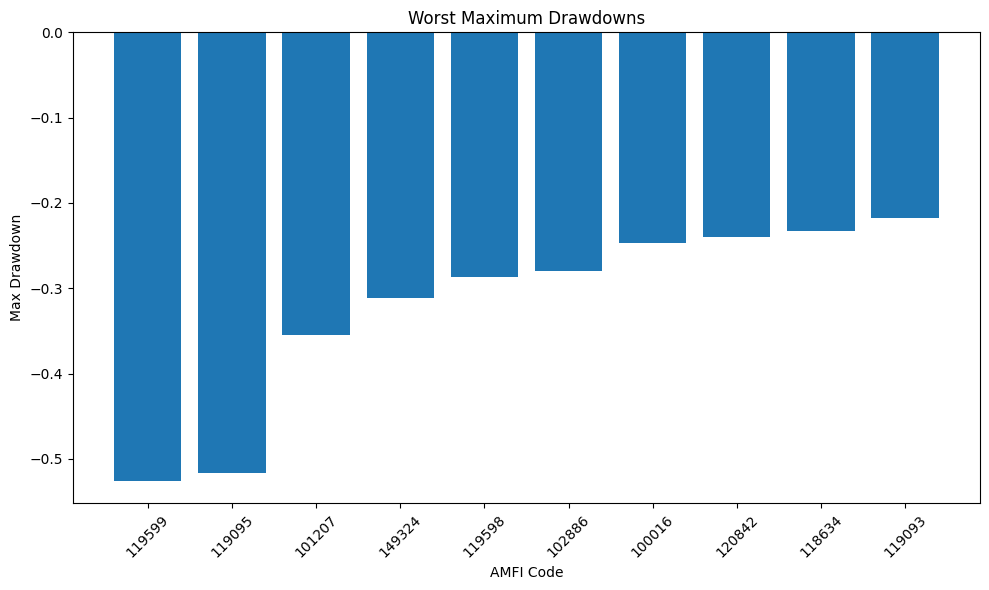

In [53]:
worst_dd = (
    max_drawdown
    .sort_values(
        by="max_drawdown"
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    worst_dd["amfi_code"].astype(str),
    worst_dd["max_drawdown"]
)

plt.title(
    "Worst Maximum Drawdowns"
)

plt.xlabel("AMFI Code")
plt.ylabel("Max Drawdown")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [57]:
max_drawdown.to_csv(
    "reports/max_drawdown.csv",
    index=False
)

### Insight

Maximum drawdown captures the worst historical decline experienced by a fund. Lower drawdowns indicate better downside protection during market stress.

In [58]:
scheme = pd.read_csv(
    "data/raw/07_scheme_performance.csv"
)

scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [59]:
scorecard = scheme[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77


In [60]:
scorecard = scorecard.merge(
    sharpe[["sharpe_ratio"]],
    left_on="amfi_code",
    right_index=True
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown,
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [61]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

In [62]:
scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [63]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30

    +

    scorecard["sharpe_rank"] * 25

    +

    scorecard["alpha_rank"] * 20

    +

    scorecard["expense_rank"] * 15

    +

    scorecard["drawdown_rank"] * 10

)

In [64]:
top_funds = (
    scorecard
    .sort_values(
        by="fund_score",
        ascending=False
    )
)

top_funds.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.000,0.675,1.000,0.5000,0.900,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,0.875,0.700,0.975,0.3625,0.925,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,0.650,0.750,0.800,0.6000,0.700,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,0.800,0.875,0.825,0.0750,0.550,69.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,0.600,1.000,0.850,0.4500,0.200,68.7500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,0.525,0.775,0.700,0.7250,0.300,63.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,0.450,0.950,0.925,0.1125,0.525,62.6875


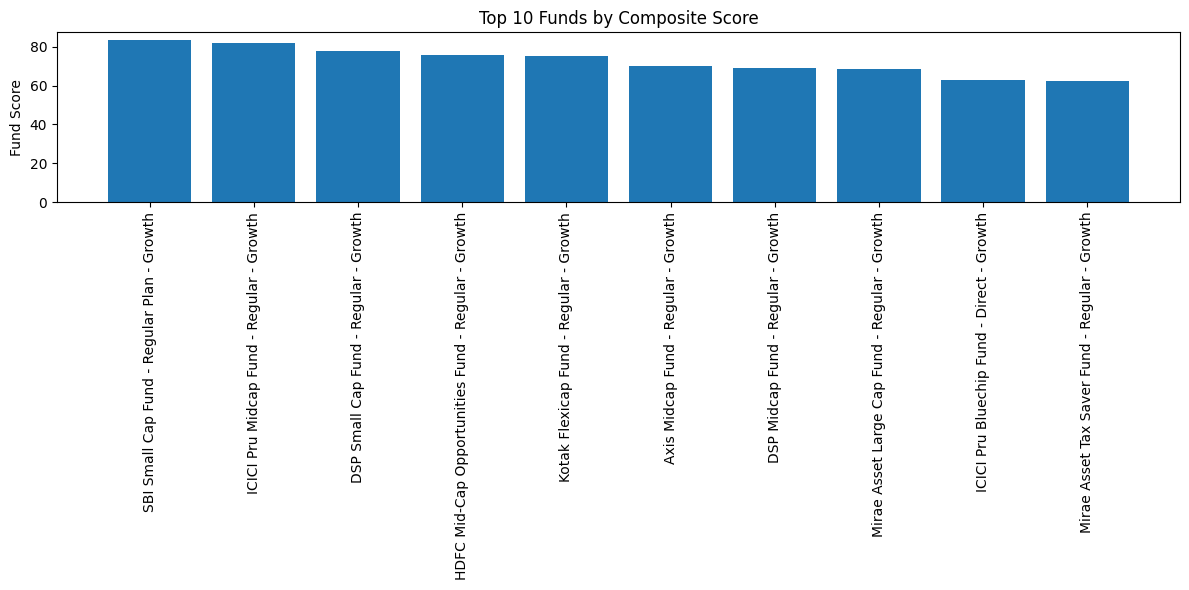

In [65]:
plt.figure(figsize=(12,6))

plt.bar(
    top_funds.head(10)["scheme_name"],
    top_funds.head(10)["fund_score"]
)

plt.title(
    "Top 10 Funds by Composite Score"
)

plt.ylabel(
    "Fund Score"
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [66]:
scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

### Insight

The composite score combines return, risk-adjusted performance, alpha generation, cost efficiency, and downside protection into a single ranking framework.

In [67]:
benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [71]:
bench = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

bench.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [69]:
bench["benchmark_return"] = (
    bench.groupby("index_name")["close_value"]
    .pct_change()
)

In [70]:
bench_pivot = bench.pivot(
    index="date",
    columns="index_name",
    values="benchmark_return"
)

In [72]:
top5_funds = top_funds["amfi_code"].head(5).values

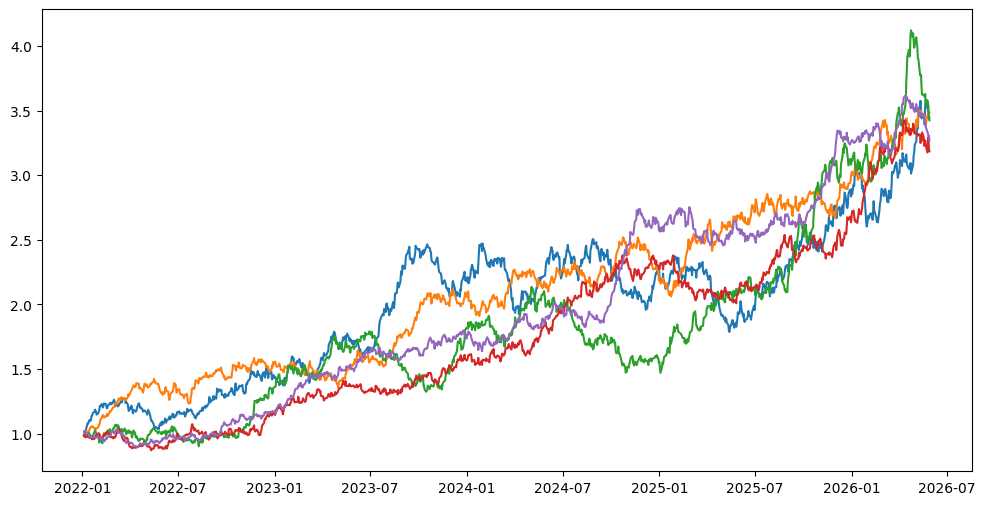

In [73]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    f = nav[nav["amfi_code"] == fund].copy()

    f = f.sort_values("date")

    f["cum_return"] = (1 + f["daily_return"]).cumprod()

    plt.plot(
        f["date"],
        f["cum_return"],
        label=f"Fund {fund}"
    )

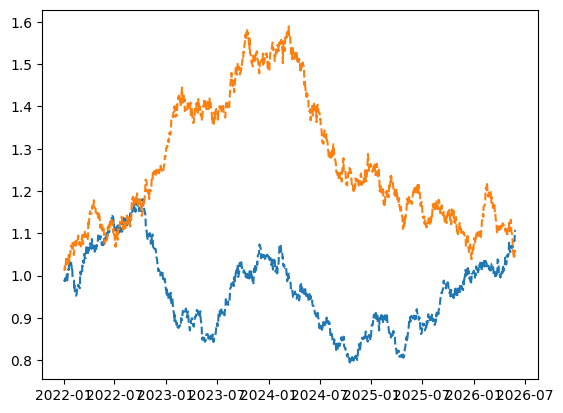

In [74]:
for col in bench_pivot.columns:

    temp = bench_pivot[col].dropna()

    cum = (1 + temp).cumprod()

    plt.plot(
        cum.index,
        cum.values,
        linestyle="--",
        label=col
    )

In [76]:
tracking_errors = []

for fund in top5_funds:

    f = nav[nav["amfi_code"] == fund]

    merged = pd.merge(
        f,
        bench_pivot,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    for col in bench_pivot.columns:

        te = np.std(
            merged["daily_return"] - merged[col]
        ) * np.sqrt(252)

        tracking_errors.append([
            fund,
            col,
            te
        ])

In [77]:
tracking_df = pd.DataFrame(
    tracking_errors,
    columns=["amfi_code", "benchmark", "tracking_error"]
)

tracking_df.to_csv(
    "reports/tracking_error.csv",
    index=False
)

### Insight

Top performing funds generally outperformed benchmark indices over the long term, though with varying levels of tracking error depending on investment strategy and risk exposure.